# simulate_fmri/ demo: a visual-motor block task

A simulated fMRI experiment on a digital brain, taken through the same
preprocessing and reconstruction as a real scan, repeated four times, and
analyzed the way an fMRI study is, with the truth at hand at every stage.

**The experiment.** The subject watches a flashing checkerboard and taps the
fingers of both hands for 20 s, then rests for 20 s, eight times: 320 s. The
visual cortex and both hand motor areas respond.

1. **The task and the sequence**: the paradigm, the haemodynamic response and
   its regional delays; the 320 s ArbEPI sequence.
2. **The study**: four repetitions simulated as raw scanner data, preprocessed
   by `preprocess/` and reconstructed by `recon.sense`, with and without the
   B0 model.
3. **One run in detail**: the raw data, the truth image and its contrast, the
   field, the activated regions.
4. **Spectra**: where the task, breathing and the heartbeat sit in frequency,
   and where they land once sampled every 0.506 s.
5. **Preprocessing and reconstruction against the truth.**
6. **Activation maps** on the anatomical image.
7. **ROC curves** against the truth.
8. **Test-retest reliability** from the four repetitions, without the truth
   (the mixed-binomial model of Genovese, Noll and Eddy), then checked with it.

`README.md` lists what is modeled, from which measurements, and what is not.
Kernel: `.venv-simulate` (see `README.md`'s setup).

**Run time.** Everything heavy is done by `simulate_fmri.study`, which skips
whatever is already on disk: with the study in `output/simulate_fmri/` this
notebook takes a few minutes. From nothing it takes about 11 hours on a
64-core machine with an RTX A6000 (measured per run: 43 s to simulate, 31 to
37 min to preprocess, a quarter of an hour to reconstruct without B0 and 1.9
hours with it) and 50 GB of disk.

In [1]:
%%capture
import os
import sys
import time
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage, signal

REPO = Path.cwd().parent if Path.cwd().name == "simulate_fmri" else Path.cwd()
os.chdir(REPO)
sys.path.insert(0, str(REPO))
warnings.simplefilter("ignore")

from preprocess import utils as pre_utils  # noqa: E402
from preprocess.coils import apply_gcc_image, apply_whitening  # noqa: E402
from recon import testbed  # noqa: E402
from simulate_fmri import analysis, study, task  # noqa: E402
from simulate_fmri.phantom import TISSUE_PROPS_3T  # noqa: E402
from simulate_fmri.session import SessionConfig  # noqa: E402

OUT = "output/simulate_fmri"
DURATION = 320.0  # s: 8 cycles of 20 s task + 20 s rest
N_RUNS = 4
cfg = SessionConfig()  # the visual-motor task is its default

In [2]:
def show(volumes: dict, center=None, contour=None, kw=None, title=""):
    # Sagittal / coronal / axial slices through `center` (default: the middle), one row per volume
    fig, axes = plt.subplots(len(volumes), 3, figsize=(9, 2.7 * len(volumes)), squeeze=False)
    for i, (row, (name, vol)) in enumerate(zip(axes, volumes.items())):
        c = [n // 2 for n in vol.shape] if center is None else center
        opts = dict(cmap="gray", vmin=0, vmax=np.nanpercentile(vol, 99.8))
        opts.update((kw or {}).get(name, {}))
        for j, (ax, view) in enumerate(zip(row, ["sagittal", "coronal", "axial"])):
            sl = [slice(None)] * 3
            sl[j] = c[j]
            im = ax.imshow(np.rot90(vol[tuple(sl)]), **opts)
            if contour is not None and contour[tuple(sl)].any():
                ax.contour(np.rot90(contour[tuple(sl)]), levels=[0.5], colors="c", linewidths=0.6)
            ax.set_xticks([])
            ax.set_yticks([])
            if i == 0:
                ax.set_title(view)
        row[0].set_ylabel(name)
        fig.colorbar(im, ax=row[2], fraction=0.046)
    fig.suptitle(title)
    plt.show()

## 1. The task and the sequence

**The paradigm** $p(t)$ is $+1$ during the task and $-1$ during rest. **The
BOLD response** of a region is the canonical haemodynamic response function
$h$ (SPM's: a gamma density peaking at 5 s minus a sixth of one peaking at
15 s, unit area) convolved with it and delayed by that region's lag $d$:

$$w(t) = (h * p)(t - d), \qquad \frac{S(t)}{\bar S} = 1 + a\,\hat w(t),$$

where $\hat w$ is $w$ with its time average removed and scaled to a peak of 1,
and $a$ is the amplitude: **3%**. A 20 s block is too short for the canonical
response to settle, so $w$ overshoots $\pm 1$ (to $\pm 1.29$) and the signal
swings from $-3\%$ to $+3\%$ about its mean, with plateaus near $\pm 2.4\%$.
(If 3% was meant as the difference between task and rest, halve it:
`Activation(..., amplitude=0.015)`.) The amplitude is that of the region's
median activated voxel in the T2*-weighted image; the simulation produces it as
a change of R2*, here $\mp 1.3\ \mathrm{s^{-1}}$.

**Regional delays.** The canonical response peaks 5.0 s after a brief event,
which is what Lin et al. (NeuroImage 2013;78:372; 3 T, 100 ms sampling, 21
subjects, a visuomotor reaction task) measured in visual cortex (5.0 ± 0.4 s).
In the same task the motor cortex's response began later and reached half its
peak **0.6 s** after the visual cortex's (3.4 vs 2.8 s; peak at 5.2 to 5.5 s),
most of it neuronal (the reaction time), not vascular. So the visual cortex
gets $d = 0$ and the motor areas $d = 0.6$ s. Differences between people are
larger than between regions (about 4 s in time to peak across 20 subjects:
Handwerker et al., NeuroImage 2004;21:1639), so these are typical values.

Activation(region='occipital', task_s=20.0, rest_s=20.0, onset=0.0, delay=0.0, amplitude=0.03, n_cycles=None)
Activation(region='motor', task_s=20.0, rest_s=20.0, onset=0.0, delay=0.6, amplitude=0.03, n_cycles=None)


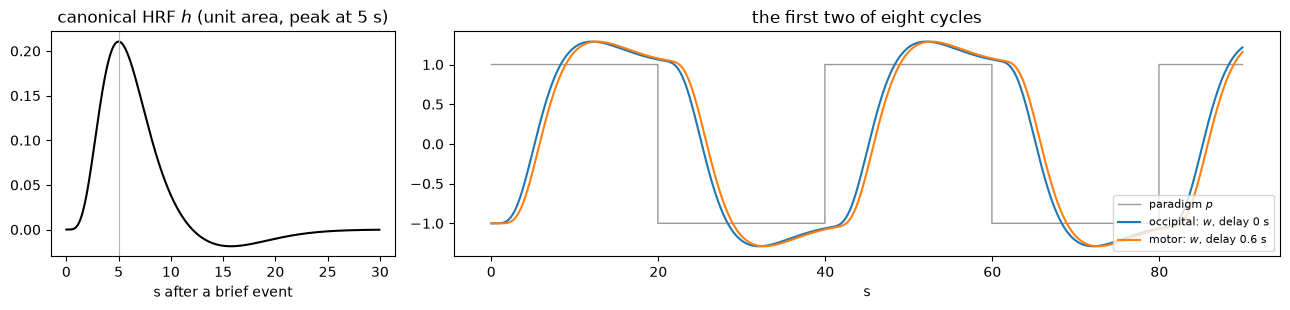

In [3]:
for act in cfg.activations:
    print(act)

t_fine = np.arange(0, 90, 0.05)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.2), width_ratios=[1, 2.4])
ax[0].plot(np.arange(0, 30, 0.05), task.canonical_hrf(np.arange(0, 30, 0.05)), "k")
ax[0].axvline(5.0, color="0.7", lw=0.8)
ax[0].set_xlabel("s after a brief event")
ax[0].set_title("canonical HRF $h$ (unit area, peak at 5 s)")
ax[1].step(t_fine, task.block_paradigm(t_fine, 20, 20, DURATION), "0.6", lw=1, label="paradigm $p$")
for act, color in zip(cfg.activations, ("C0", "C1")):
    w = task.bold_response(t_fine, act.task_s, act.rest_s, DURATION, act.onset, act.delay)
    ax[1].plot(t_fine, w, color, label=f"{act.region}: $w$, delay {act.delay:g} s")
ax[1].set_xlabel("s")
ax[1].set_title("the first two of eight cycles")
ax[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

**The sequence.** `study.make_scan_info` generates `params.py`'s ArbEPI and
deGRE sequences for a 320 s run and returns their `scan_info.mat`: where in
(ky, kz) and when every echo of every shot of every frame is acquired. To
simulate another protocol, edit `params.py`; to simulate a past session, use
its `scan_info.mat`.

In [4]:
%%capture --no-stdout
SCAN_INFO = study.make_scan_info(OUT, DURATION)
with h5py.File(SCAN_INFO) as f:
    etl, n_shots, n_frames = f["schedules"].shape[1:]
    vol_tr = float(np.ravel(f["volume_tr"][()])[0]) if "volume_tr" in f else float("nan")
print(f"{n_frames} frames x {n_shots} shots x {etl} echoes; "
      f"{n_frames} x {vol_tr:.3f} s = {n_frames * vol_tr:.1f} s")

632 frames x 10 shots x 54 echoes; 632 x 0.506 s = 319.8 s


## 2. The study: four repetitions

`study.run_repetitions` simulates each run as raw scanner data
(`simulate_fmri.session`), runs `preprocess/` on it, and reconstructs it with
`recon.sense` (L1-wavelet + TV, temporal high-pass penalty), once ignoring the
field and once with the estimated B0 map. Runs differ only in their seed: fresh
thermal noise and fresh physiological noise; the same brain, field, coils,
sequence and task. Every step is skipped when its output exists.

Two settings in `study.RECONS` are worth knowing. The B0 operator's norm
`sigma1A` is passed (1.5) so that no power iteration runs: it took 75 minutes
on a 60 s run and returned 1.488. And the B0 model uses 16 time segments,
not the default 32: on this protocol (a 31 ms echo train) 16 segments are
within 0.001% of 64, at half the cost.

**A run is reconstructed in four pieces.** The solver reconstructs all frames
of a piece together and keeps about 35 copies of the image series in GPU
memory; 632 frames, and 316, did not fit in 48 GB, so `study.MAX_FRAMES` cuts
the run into four pieces of 158 frames (80 s, two task cycles), which peak at
38 GB. The pieces are joined into one series, but they are independent
reconstructions, so there is a **seam** at 80, 160 and 240 s: a step between
two frames that is several times the usual one, and a larger error for about
three frames either side. The seams are marked with thin red lines on the
reconstructed time courses below, and section 6 checks that they do not change
the activation maps.

In [5]:
%%capture study_log
t0 = time.time()
runs = study.run_repetitions(SCAN_INFO, OUT, N_RUNS, cfg=cfg)
print(f"{(time.time() - t0) / 60:.0f} min")

In [6]:
print(study_log.stdout.splitlines()[-1], "(this execution)")  # noqa: F821 -- set by %%capture
for k, run in enumerate(runs):
    print(f"run {k + 1}: {run['dir']}")
    for label, fn in run["recons"].items():
        size = os.path.getsize(fn) / 1e9
        print(f"    {label:6s} {os.path.relpath(fn, run['dir'])}  {size:.1f} GB")
truths = [analysis.load_truth(run["truth"]) for run in runs]
truth, run1 = truths[0], runs[0]
brain = truth.brain
TR, names, rois = truth.volume_tr, truth.roi_names, truth.roi_masks
t_frame = (np.arange(truth.n_frames) + 0.5) * TR
t_exc = np.arange(truth.n_frames * truth.n_shots) * truth.tr_shot
centers = {name: np.round(np.argwhere(roi).mean(axis=0)).astype(int)
           for name, roi in zip(names, rois)}
# the motor region is two-sided: slice through its left half rather than between the halves
left = rois[1] & (np.arange(rois.shape[1])[:, None, None] < rois.shape[1] // 2)
centers[names[1]] = np.round(np.argwhere(left).mean(axis=0)).astype(int)
for name, roi, amp in zip(names, rois, truth.amps):
    print(f"{name}: {roi.sum()} activated voxels, amplitude {100 * amp:.2f}%")
# where the separately reconstructed pieces of a run meet: the first frame of each later piece
with h5py.File(run1["recons"]["B0"]) as f:
    SEAMS = [int(a) for a, _ in f.attrs.get("frame_chunks", [[0, 0]])][1:]
print(f"seams between reconstructed pieces: frames {SEAMS}, at "
      + ", ".join(f"{s * TR:.0f}" for s in SEAMS) + " s")


def mark_seams(ax):
    for s in SEAMS:
        ax.axvline(s * TR, color="r", lw=0.5, alpha=0.7)

0 min (this execution)
run 1: output/simulate_fmri/run1
    no B0  recon/sense_wavelet-tv_hp3/task_recon.h5  2.5 GB
    B0     recon/sense_wavelet-tv_b0_hp3/task_recon.h5  2.5 GB
run 2: output/simulate_fmri/run2
    no B0  recon/sense_wavelet-tv_hp3/task_recon.h5  2.5 GB
    B0     recon/sense_wavelet-tv_b0_hp3/task_recon.h5  2.5 GB
run 3: output/simulate_fmri/run3
    no B0  recon/sense_wavelet-tv_hp3/task_recon.h5  2.5 GB
    B0     recon/sense_wavelet-tv_b0_hp3/task_recon.h5  2.5 GB
run 4: output/simulate_fmri/run4
    no B0  recon/sense_wavelet-tv_hp3/task_recon.h5  2.5 GB
    B0     recon/sense_wavelet-tv_b0_hp3/task_recon.h5  2.5 GB


block_occipital: 609 activated voxels, amplitude 3.00%
block_motor: 422 activated voxels, amplitude 3.00%
seams between reconstructed pieces: frames [158, 316, 474], at 80, 160, 240 s


## 3. One run in detail

What a scan would leave: four archives of raw readouts in acquisition order
(kept for run 1 only), and the sequence's record.

task_noise.h5    noise   readouts (205, 32, 100)        5 MB
task_cal.h5      EPIcal  readouts (540, 32, 100)       14 MB
gre.h5           deGRE   readouts (7488, 32, 72)      138 MB
task_epi.h5      ArbEPI  readouts (341280, 32, 100)     8737 MB


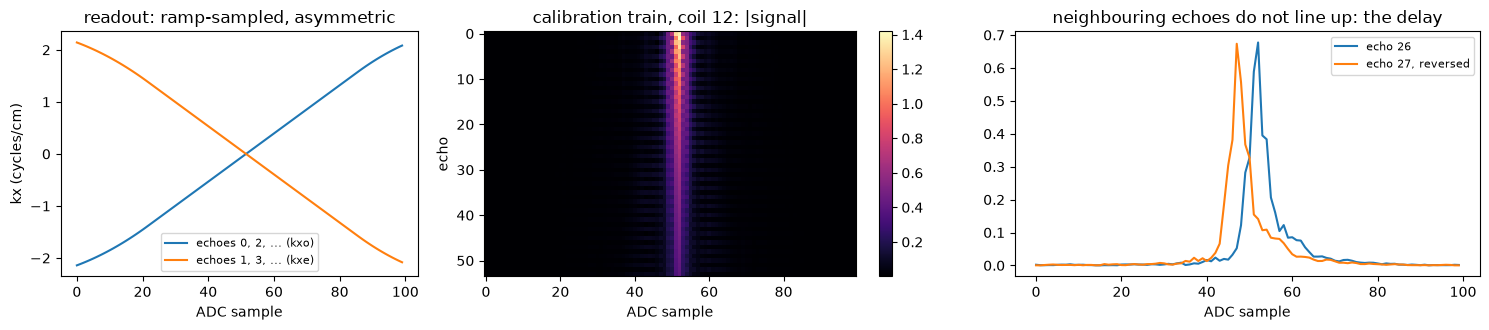

In [7]:
raw = os.path.join(run1["dir"], "scanarchives")
for fn, scan in (("task_noise.h5", "noise"), ("task_cal.h5", "EPIcal"), ("gre.h5", "deGRE"),
                 ("task_epi.h5", "ArbEPI")):
    with h5py.File(os.path.join(raw, fn)) as f:
        print(f"{fn:16s} {scan:7s} readouts {f['readouts'].shape}  "
              f"{os.path.getsize(os.path.join(raw, fn)) / 1e6:7.0f} MB")

kxo, kxe = pre_utils.load_kxoe(SCAN_INFO)
with h5py.File(os.path.join(raw, "task_cal.h5")) as f:
    train = f["readouts"][:etl]  # one blip-free echo train, (ETL, Ncoils, Nfid)
coil = np.argmax(np.abs(train).sum(axis=(0, 2)))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.4), width_ratios=[1, 1.3, 1.3])
ax[0].plot(kxo, label="echoes 0, 2, ... (kxo)")
ax[0].plot(kxe, label="echoes 1, 3, ... (kxe)")
ax[0].set_xlabel("ADC sample")
ax[0].set_ylabel("kx (cycles/cm)")
ax[0].set_title("readout: ramp-sampled, asymmetric")
ax[0].legend(fontsize=8)
im = ax[1].imshow(np.abs(train[:, coil]), aspect="auto", cmap="magma")
ax[1].set_xlabel("ADC sample")
ax[1].set_ylabel("echo")
ax[1].set_title(f"calibration train, coil {coil}: |signal|")
plt.colorbar(im, ax=ax[1])
ax[2].plot(np.abs(train[26, coil]), label="echo 26")
ax[2].plot(np.abs(train[27, coil])[::-1], label="echo 27, reversed")
ax[2].set_xlabel("ADC sample")
ax[2].set_title("neighbouring echoes do not line up: the delay")
ax[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Is the truth image T2*-weighted?

Yes, and it should look flatter than the EPI images one is used to. Each
tissue's signal is its proton density times the spoiled steady state at the
**per-shot** TR and flip angle, times $e^{-TE/T_2^*}$. The table compares that
prediction with the truth image in voxels that are purely one tissue.

The T2* decay is there: by TE = 30 ms gray matter is down to 0.61 and white
matter to 0.58 of its signal, and the BOLD change is a change of that factor.
What is unusual is the T1 weighting on top of it. A 3D-EPI excites the whole
volume every shot: TR is 50.6 ms and the flip angle 15.9°, where a 2D
multi-slice EPI has seconds and 70 to 90°. At 50 ms CSF (T1 4 s) is saturated
to half of gray matter's steady state, which cancels the brightness its long
T2* gives it in a 2D EPI, and white matter (short T1) ends up slightly
brighter than gray. The three tissues come out within 10% of each other.

The two reference images below are the same tissue maps with other weightings.
Without the T2* decay (TE = 0) this sequence would give a plainly T1-weighted
image, with CSF at 0.58 of gray matter: the T2* weighting is what lifts CSF
back to the level of tissue. At a 2D EPI's TR and flip angle (2 s, 77°) CSF
edges ahead of gray matter again and white matter falls behind it.

TE 30.0 ms, per-shot TR 50.6 ms, flip 15.9 deg

          T1    T2*    PD |  steady  decay | predicted  in truth | no decay  TR 2 s, 77 deg
gm      1331   59.7  0.86 |  0.1379  0.605 |     1.000     1.000 |    1.000           1.000
wm       832   54.6  0.77 |  0.1701  0.577 |     1.054     1.054 |    1.105           0.969
csf     4000 2000.0  1.00 |  0.0684  0.985 |     0.940     0.958 |    0.577           1.054

(the last four columns are relative to gray matter)


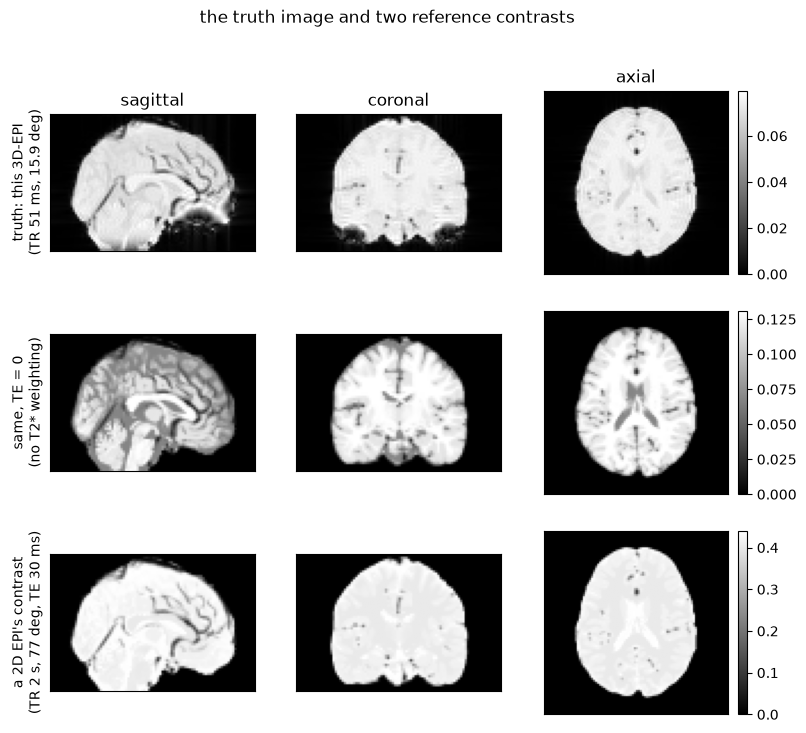

In [8]:
def gre(t1_ms, tr_s, fa_deg):
    e1, a = np.exp(-tr_s * 1e3 / t1_ms), np.deg2rad(fa_deg)
    return np.sin(a) * (1 - e1) / (1 - np.cos(a) * e1)


with h5py.File(run1["truth"]) as f:
    fa, b0_true = f["truth"].attrs["fa"], f["truth/b0_map"][()]
    snr0 = f["truth"].attrs["snr0"]
te_ms, tr_shot_ms = 1e3 * truth.te, 1e3 * truth.tr_shot
print(f"TE {te_ms:.1f} ms, per-shot TR {tr_shot_ms:.1f} ms, flip {fa:.1f} deg\n")
print(f"{'':5s} {'T1':>6s} {'T2*':>6s} {'PD':>5s} | {'steady':>7s} {'decay':>6s} | "
      f"{'predicted':>9s} {'in truth':>9s} | {'no decay':>8s} {'TR 2 s, 77 deg':>15s}")
weights_3d, weights_2d, weights_te0, ref = {}, {}, {}, None
for lab in ("gm", "wm", "csf"):
    t1, _, t2s, pd, _ = TISSUE_PROPS_3T[lab]
    steady, decay = gre(t1, truth.tr_shot, fa), np.exp(-te_ms / t2s)
    weights_3d[lab], weights_te0[lab] = pd * steady * decay, pd * steady
    weights_2d[lab] = pd * gre(t1, 2.0, 77.0) * decay
    measured = np.median(truth.image_rest[truth.tissues[lab] > 0.97])
    ref = ref or (weights_3d[lab], measured, weights_te0[lab], weights_2d[lab])
    print(f"{lab:5s} {t1:6.0f} {t2s:6.1f} {pd:5.2f} | {steady:7.4f} {decay:6.3f} | "
          f"{weights_3d[lab] / ref[0]:9.3f} {measured / ref[1]:9.3f} | "
          f"{weights_te0[lab] / ref[2]:8.3f} {weights_2d[lab] / ref[3]:15.3f}")
print("\n(the last four columns are relative to gray matter)")


def synth(weights):
    # the tissue maps weighted as another contrast (no field, no dephasing)
    return sum(weights[lab] * truth.tissues[lab] for lab in weights)


c = [45, 45, 30]
show({"truth: this 3D-EPI\n(TR 51 ms, 15.9 deg)": truth.x0,
      "same, TE = 0\n(no T2* weighting)": synth(weights_te0),
      "a 2D EPI's contrast\n(TR 2 s, 77 deg, TE 30 ms)": synth(weights_2d)}, center=c,
     title="the truth image and two reference contrasts")

The field and the activated regions. The field map is what a field map of
this scan could measure; the activation is the true amplitude (the peak
fractional change of each voxel), laid over the truth file's T1-weighted
anatomical image (`truth/anat/t1w`, on the simulation's 1.2 mm spin grid), with
the activated voxels of each region outlined.

SNR of a fully sampled volume: 115;  field over the brain: std 28 Hz, -144 to 272 Hz


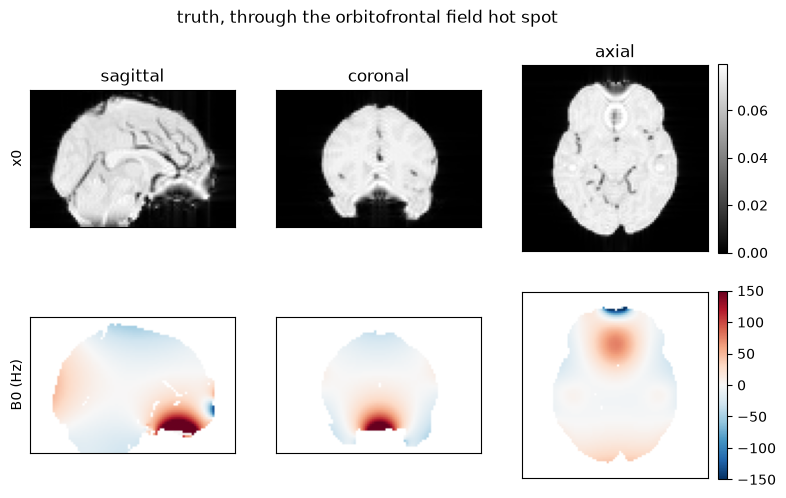

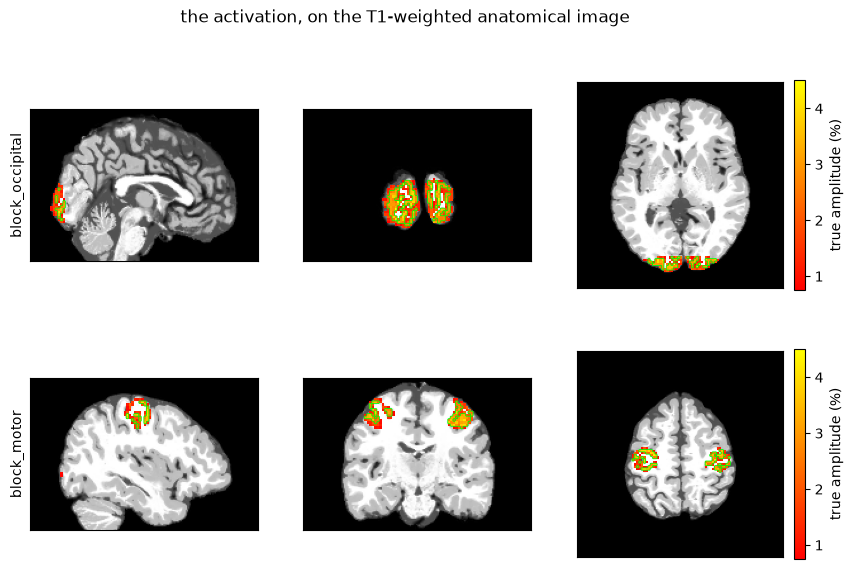

In [9]:
print(f"SNR of a fully sampled volume: {snr0:.0f};  field over the brain: "
      f"std {b0_true[brain].std():.0f} Hz, {np.percentile(b0_true[brain], 0.1):.0f} to "
      f"{np.percentile(b0_true[brain], 99.9):.0f} Hz")
show({"x0": truth.x0, "B0 (Hz)": np.where(brain, b0_true, np.nan)}, center=[45, 60, 18],
     kw={"B0 (Hz)": dict(cmap="RdBu_r", vmin=-150, vmax=150)},
     title="truth, through the orbitofrontal field hot spot")
fig = analysis.overlay(truth, 100 * truth.amp_map, threshold=0.75, centers=centers, vmax=4.5,
                       outline=rois.any(axis=0), two_sided=False, label="true amplitude (%)",
                       title="the activation, on the T1-weighted anatomical image")
plt.show()

## 4. Spectra: the task, breathing, the heartbeat, and aliasing

The simulation updates every signal source at every **excitation** (every
50.6 ms, 19.8 Hz), but an image is one **frame** of ten excitations: the series
is sampled every 0.506 s, 1.98 Hz, and nothing above the Nyquist frequency of
0.99 Hz can be represented. What is faster folds back.

| source | true frequency | in the image series |
|---|---|---|
| task | 0.025 Hz and odd harmonics (0.075, 0.125, ...) | the same |
| BOLD-like resting fluctuations | 0.01 to 0.1 Hz | the same: **they share the task's band** |
| breathing | 0.25 Hz | the same |
| heartbeat | 1.1 Hz | **aliased to 0.88 Hz** |
| heartbeat, 2nd harmonic | 2.2 Hz | **aliased to 0.22 Hz**, next to breathing |

A multi-shot frame also averages over its 0.506 s, which attenuates an
oscillation at $f$ by $|\mathrm{sinc}(f \cdot 0.506\,\mathrm{s})|$: the
heartbeat survives at 0.56 of its size, its second harmonic at 0.10.

The spectrograms below are of the **true, noise-free signal** (from the truth
file's modes) in the visual region and in CSF, first at the excitation rate,
then as a frame samples it; the last row is the **reconstructed** series of
the same voxels. The reconstruction's temporal high-pass penalty acts above
0.15 Hz, which is where breathing and both aliased cardiac lines are. The thin
red lines on the last row are the seams between the reconstructed pieces
(section 2): a step in the series is broadband, so a seam can show as a
vertical stripe as wide as the 80 s analysis window. It is not physiology.

sampling: 19.76 Hz per excitation, 1.976 Hz per frame (Nyquist 0.988 Hz)

                            true (Hz)  in the series (Hz)  frame-average gain
task                            0.025               0.025                1.00
task, 3rd harmonic              0.075               0.075                1.00
breathing                       0.250               0.250                0.97
heartbeat                       1.100               0.876 (aliased)      0.56
heartbeat, 2nd harmonic         2.200               0.224 (aliased)      0.10


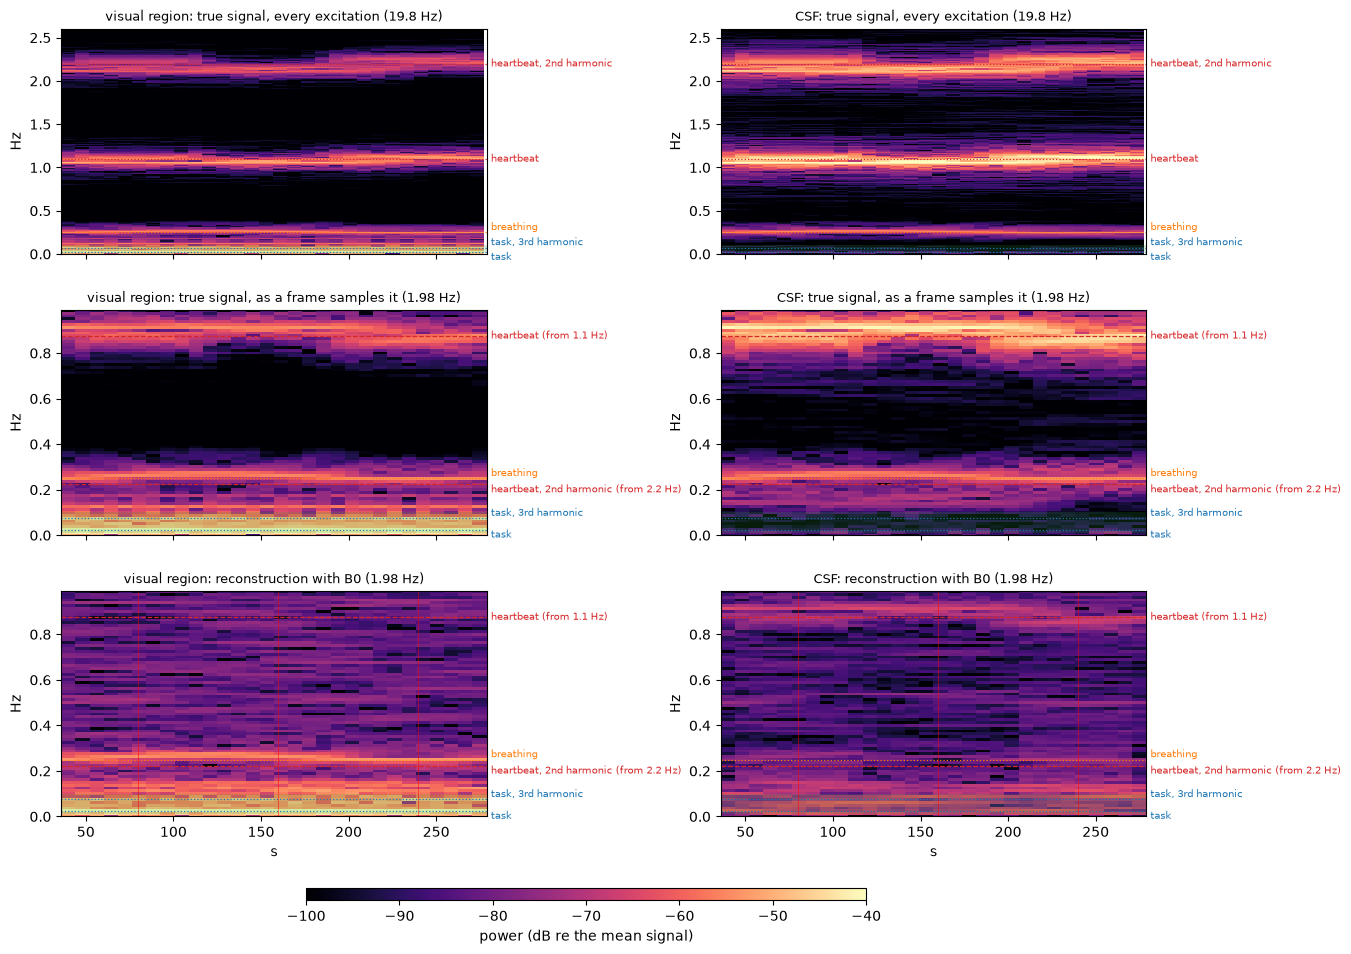

In [10]:
fs_exc, fs_frame = 1 / truth.tr_shot, 1 / TR
bands = {  # name: (true frequency in Hz or (low, high), color)
    "task": (0.025, "C0"), "task, 3rd harmonic": (0.075, "C0"),
    "BOLD-like": ((0.01, 0.1), "C2"),
    "breathing": (0.25, "C1"),
    "heartbeat": (1.1, "C3"), "heartbeat, 2nd harmonic": (2.2, "C3"),
}
print(f"sampling: {fs_exc:.2f} Hz per excitation, {fs_frame:.3f} Hz per frame "
      f"(Nyquist {fs_frame / 2:.3f} Hz)\n")
print(f"{'':26s} {'true (Hz)':>10s} {'in the series (Hz)':>19s} {'frame-average gain':>19s}")
for name, (f0, _) in bands.items():
    if not isinstance(f0, tuple):
        folded = float(analysis.alias(f0, fs_frame))
        note = " (aliased)" if abs(folded - f0) > 1e-9 else ""
        print(f"{name:26s} {f0:10.3f} {folded:19.3f}{note:10s}"
              f" {float(analysis.frame_average_gain(f0, TR)):9.2f}")

csf = (truth.tissues["csf"] > 0.9) & brain
regions = {"visual region": rois[0], "CSF": csf}
series_b0 = {name: analysis.load_series(run1["recons"]["B0"], m).mean(axis=0)
             for name, m in regions.items()}


def spectrogram(ax, x, fs, fmax, window_s):
    nper = int(round(window_s * fs))
    f, tt, s = signal.spectrogram(x - x.mean(), fs=fs, nperseg=nper, noverlap=int(0.9 * nper),
                                  detrend="linear", scaling="spectrum")
    keep = f <= fmax
    im = ax.pcolormesh(tt, f[keep], 10 * np.log10(s[keep] + 1e-16), shading="auto", cmap="magma",
                       vmin=-100, vmax=-40)
    ax.set_ylim(0, fmax)
    return im


def mark(ax, fs, fmax, aliased):
    for name, (f0, color) in bands.items():
        if isinstance(f0, tuple):
            ax.axhspan(*f0, color=color, alpha=0.18, lw=0)
            continue
        f_shown = float(analysis.alias(f0, fs)) if aliased else f0
        if f_shown <= fmax:
            moved = aliased and abs(f_shown - f0) > 1e-9
            ax.axhline(f_shown, color=color, lw=0.9, ls="--" if moved else ":")
            # neighbours (task and its harmonic; breathing and the aliased 2nd harmonic) share a
            # height: put one label above its line and the other below
            va = {"task": "top", "task, 3rd harmonic": "bottom", "breathing": "bottom",
                  "heartbeat, 2nd harmonic": "top" if moved else "center"}.get(name, "center")
            ax.text(1.01, f_shown, name + (f" (from {f0:g} Hz)" if moved else ""), color=color,
                    fontsize=7, va=va, transform=ax.get_yaxis_transform())


fig, axes = plt.subplots(3, 2, figsize=(14, 10.5), sharex=True)
fig.subplots_adjust(wspace=0.55, hspace=0.25, bottom=0.13)
for col, (name, m) in enumerate(regions.items()):
    true_exc = analysis.true_signal(truth, m).mean(axis=0)
    true_frame = analysis.true_signal(truth, m, per_frame=True).mean(axis=0)
    recon = series_b0[name] / series_b0[name].mean()
    rows = [(true_exc, fs_exc, 2.6, False, "true signal, every excitation (19.8 Hz)"),
            (true_frame, fs_frame, fs_frame / 2, True,
             "true signal, as a frame samples it (1.98 Hz)"),
            (recon, fs_frame, fs_frame / 2, True, "reconstruction with B0 (1.98 Hz)")]
    for ax, (x, fs, fmax, aliased, label) in zip(axes[:, col], rows):
        im = spectrogram(ax, x, fs, fmax, window_s=80.0)
        mark(ax, fs, fmax, aliased)
        ax.set_title(f"{name}: {label}", fontsize=9)
        ax.set_ylabel("Hz")
    mark_seams(axes[-1, col])
    axes[-1, col].set_xlabel("s")
fig.colorbar(im, cax=fig.add_axes([0.3, 0.05, 0.4, 0.012]), orientation="horizontal",
             label="power (dB re the mean signal)")
plt.show()

The same content as power spectra of the whole run, on a logarithmic frequency
axis, where the low band is easier to read: the task's line at 0.025 Hz stands
on the BOLD-like fluctuations that fill 0.01 to 0.1 Hz.

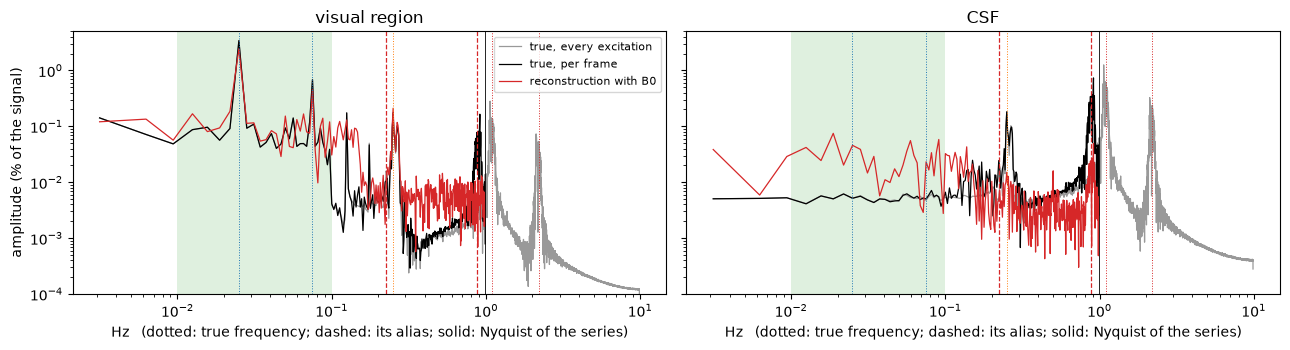

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for ax, (name, m) in zip(axes, regions.items()):
    for x, fs, label, style in (
            (analysis.true_signal(truth, m).mean(axis=0), fs_exc, "true, every excitation", "0.6"),
            (analysis.true_signal(truth, m, per_frame=True).mean(axis=0), fs_frame,
             "true, per frame", "k"),
            (series_b0[name] / series_b0[name].mean(), fs_frame, "reconstruction with B0", "C3")):
        f, p = signal.periodogram(x - x.mean(), fs=fs, detrend="linear", scaling="spectrum")
        ax.loglog(f[1:], 100 * np.sqrt(2 * p[1:]), style, lw=0.9, label=label)
    for bname, (f0, color) in bands.items():
        if isinstance(f0, tuple):
            ax.axvspan(*f0, color=color, alpha=0.15, lw=0)
        else:
            ax.axvline(f0, color=color, lw=0.7, ls=":")
            folded = float(analysis.alias(f0, fs_frame))
            if abs(folded - f0) > 1e-9:
                ax.axvline(folded, color=color, lw=0.9, ls="--")
    ax.axvline(fs_frame / 2, color="k", lw=0.6)
    ax.set_xlabel("Hz   (dotted: true frequency; dashed: its alias; solid: Nyquist of the series)")
    ax.set_title(name)
    ax.set_ylim(1e-4, 5)
axes[0].set_ylabel("amplitude (% of the signal)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Preprocessing and reconstruction against the truth

What `preprocess/` calibrated and estimated on run 1, against what the
simulation put in.

In [12]:
with h5py.File(run1["truth"]) as f:
    g = f["truth"]
    sim = dict(g.attrs)
    oe_true, smaps_true = g["oe_phase"][()], g["smaps"][()]
    b0_true_degre = g["degre/b0_map"][()]
with h5py.File(run1["preprocessed"]) as f:
    a = dict(f.attrs)
    oe = np.asarray(a["oephase_a"]).reshape(-1, 2)
    smaps, W, GCC = f["smaps"][()], f["W"][()], f["GCC"][()]
    r2s_est = f["r2star_map"][()]
    b0_est_degre, mask_degre = f["degre/b0_map"][()], f["degre/mask"][()] > 0

# sensitivity maps: the true ones, taken through the same whitening and compression
st = apply_gcc_image(apply_whitening(smaps_true, W), GCC)
num = np.abs((smaps.conj() * st).sum(-1))
den = np.sqrt((np.abs(smaps) ** 2).sum(-1) * (np.abs(st) ** 2).sum(-1))
agree = np.divide(num, den, out=np.zeros_like(num), where=den > 0)
err_b0 = np.abs(b0_est_degre - b0_true_degre)[mask_degre]
gm, wm = truth.tissues["gm"] > 0.9, truth.tissues["wm"] > 0.9

rows = [
    ("readout delay (samples)", f"{sim['delay']:+.2f}", f"{a['delay']:+.2f}"),
    ("odd/even phase, first / last echo pair (rad)",
     f"{oe_true[0, 0]:+.3f} / {oe_true[-1, 0]:+.3f}", f"{oe[0, 0]:+.3f} / {oe[-1, 0]:+.3f}"),
    ("noise variance after whitening", "1", f"{a['noise_var']:.2f}"),
    ("coils", f"{a['Ncoils']}", f"{a['Nc_out']} virtual"),
    ("sensitivity maps: agreement per brain voxel, median", "1", f"{np.median(agree[brain]):.4f}"),
    ("B0 map, deGRE grid: |error| median / 90th pct (Hz)",
     f"field std {b0_true_degre[mask_degre].std():.0f}",
     f"{np.median(err_b0):.1f} / {np.percentile(err_b0, 90):.1f}"),
    ("R2* in gray / white matter (1/s)", "16.8 / 18.3",
     f"{np.median(r2s_est[gm]):.1f} / {np.median(r2s_est[wm]):.1f}"),
]
print(f"{'':52s} {'simulated':>16s} {'preprocess':>16s}")
for name, s_, p_ in rows:
    print(f"{name:52s} {s_:>16s} {p_:>16s}")

                                                            simulated       preprocess
readout delay (samples)                                         -0.30            -0.30
odd/even phase, first / last echo pair (rad)          -0.250 / -0.320  -0.263 / -0.338
noise variance after whitening                                      1             0.96
coils                                                              32       19 virtual
sensitivity maps: agreement per brain voxel, median                 1           0.9979
B0 map, deGRE grid: |error| median / 90th pct (Hz)       field std 30        0.3 / 3.5
R2* in gray / white matter (1/s)                          16.8 / 18.3      16.2 / 18.2


`recon.testbed.score` compares each reconstruction's magnitude with the truth
after one global scale: the error of the mean image and of each frame, the
temporal fluctuation of voxels outside the activations (which includes the
simulated physiological noise, so it is not zero even for a perfect
reconstruction), and for each activated region the recovered amplitude (1 =
exact), its t-score, the correlation of its mean time course with the truth,
and the leakage around it. `_t_lowband` and `false_pos_frac_lowband` are the
calibrated ones: a GLM on the temporal frequencies below 0.15 Hz only, with
the degrees of freedom that band has.

In [13]:
scores = {label: testbed.score(run1["truth"], fn) for label, fn in run1["recons"].items()}
print(f"{'run 1':34s} " + " ".join(f"{label:>10s}" for label in scores))
for key in scores["B0"]:
    print(f"{key:34s} " + " ".join(f"{s[key]:10.3f}" for s in scores.values()))

run 1                                   no B0         B0
alpha                                   0.001      0.001
object_thresh                           0.100      0.100
nrmse_mean_pct                         23.201     10.712
nrmse_frame_pct                        23.914     10.901
fluct_pct                               5.071      1.192
fluct_inband_pct                        4.814      1.151
fluct_outband_pct                       1.547      0.310
block_occipital_t_lowband               1.278     12.555
block_occipital_amp_ratio               0.269      0.723
block_occipital_t                       3.183     31.345
block_occipital_corr                    0.318      0.961
block_occipital_leak_ratio              0.170      0.079
block_motor_t_lowband                   3.597     11.245
block_motor_amp_ratio                   0.628      0.482
block_motor_t                           8.934     27.888
block_motor_corr                        0.726      0.933
block_motor_leak_ratio         

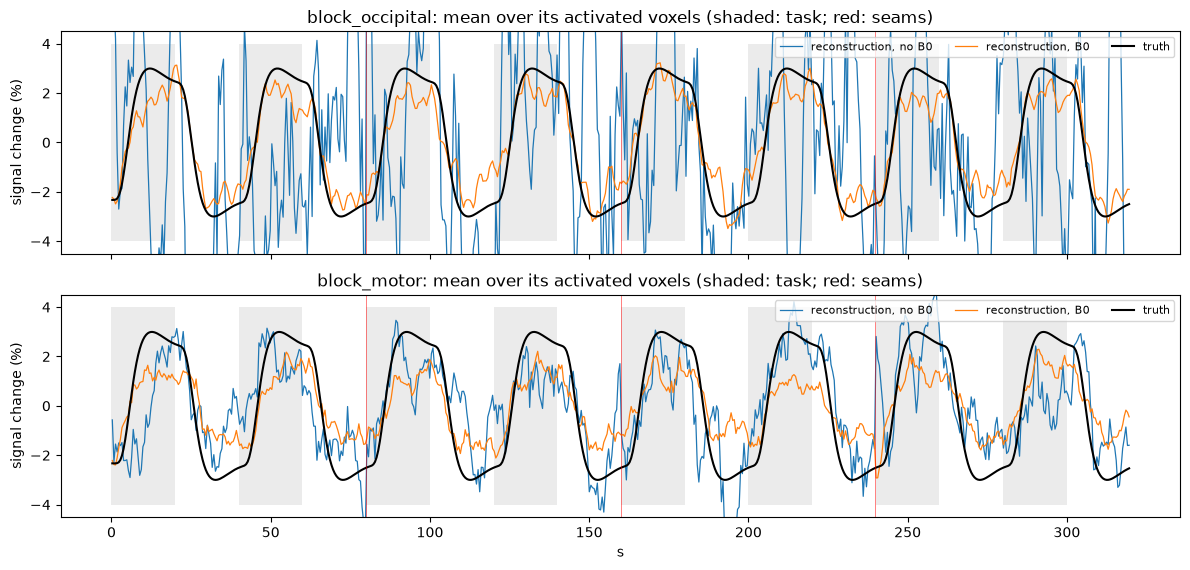

In [14]:
series_roi = {label: [analysis.load_series(fn, roi) for roi in rois]
              for label, fn in run1["recons"].items()}
fig, axes = plt.subplots(len(rois), 1, figsize=(12, 2.9 * len(rois)), sharex=True, squeeze=False)
for k, (ax, name) in enumerate(zip(axes[:, 0], names)):
    ax.fill_between(t_exc, -4, 4, where=truth.paradigm[k] > 0, color="0.92", lw=0)
    for label, color in (("no B0", "C0"), ("B0", "C1")):
        s = series_roi[label][k]
        s = (s / s.mean(axis=1, keepdims=True)).mean(axis=0)
        ax.plot(t_frame, 100 * (s - s.mean()), color, lw=0.9, label=f"reconstruction, {label}")
    ax.plot(t_frame, 100 * truth.amps[k] * truth.waveforms[k], "k", label="truth")
    ax.set_ylabel("signal change (%)")
    ax.set_ylim(-4.5, 4.5)
    mark_seams(ax)
    ax.set_title(f"{name}: mean over its activated voxels (shaded: task; red: seams)")
    ax.legend(fontsize=8, loc="upper right", ncol=3)
axes[-1, 0].set_xlabel("s")
plt.tight_layout()
plt.show()

### Temporal standard deviation over the mean

The map called "temporal std / truth" in the scorer's panel is, for each voxel,
the standard deviation of its reconstructed time series divided by its true
mean signal: the size of the voxel's fluctuation as a fraction of its signal,
the reciprocal of temporal SNR. Dark is stable.

It does not separate the fluctuation that belongs in the image from the one the
measurement added. Here the two can be told apart, because the true series is
known: the left column is the same quantity for the **true** signal (the
task in the activated regions, the BOLD-like patterns in gray matter, the
heartbeat in CSF), the middle is the reconstruction, and the right is their
ratio. A ratio of 1 means the reconstruction's fluctuation is all real; above
1 it added noise or artifacts (the orbitofrontal region, where the field is
steep); below 1 it smoothed real fluctuation away.

temporal std / mean, median over the brain: true 0.71%, reconstruction with B0 1.26%  (temporal SNR 79)


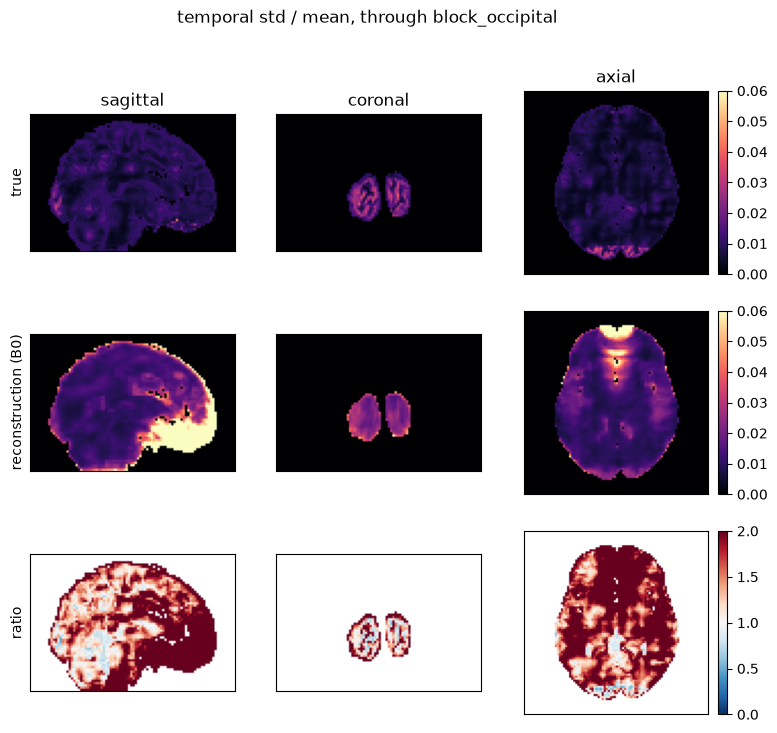

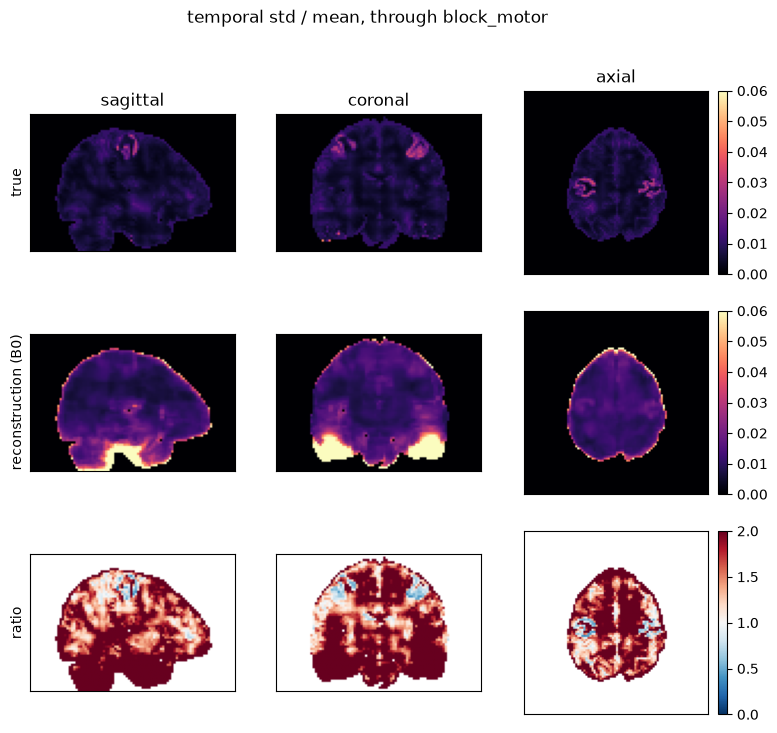

In [15]:
true_frames = analysis.true_signal(truth, brain, per_frame=True)
std_true = analysis.to_volume(true_frames.std(axis=1) / true_frames.mean(axis=1), brain)
x_b0 = analysis.load_series(run1["recons"]["B0"], brain)
std_recon = analysis.to_volume(x_b0.std(axis=1) / x_b0.mean(axis=1), brain)
ratio = np.divide(std_recon, std_true, out=np.full_like(std_recon, np.nan), where=std_true > 0)
print(f"temporal std / mean, median over the brain: true {100 * np.median(std_true[brain]):.2f}%, "
      f"reconstruction with B0 {100 * np.median(std_recon[brain]):.2f}%  "
      f"(temporal SNR {1 / np.median(std_recon[brain]):.0f})")
kw = dict(cmap="magma", vmin=0, vmax=0.06)
for name in names:
    show({"true": std_true, "reconstruction (B0)": std_recon, "ratio": ratio},
         center=list(centers[name]),
         kw={"true": kw, "reconstruction (B0)": kw, "ratio": dict(cmap="RdBu_r", vmin=0, vmax=2)},
         title=f"temporal std / mean, through {name}")

## 6. Activation maps

The analysis a study would run: a GLM of every voxel's series on the task
regressor (the paradigm convolved with the canonical HRF, **without** the
regional delays, which an analysis does not know), a constant and a linear
trend. The t-map is thresholded at the value a nominal p < 0.001 (two-sided,
uncorrected) gives, and the surviving voxels are laid over the T1-weighted
anatomical image; the green outline is the truly activated region. Whether
that threshold really passes one inactive voxel in a thousand is measured
below, since here the inactive voxels are known.

The GLM is fitted on the temporal frequencies below 0.15 Hz, which gives it 93
degrees of freedom instead of 629. The series has far fewer independent
samples than frames: the reconstruction's temporal penalty and the slow
physiological fluctuations both leave the residual smooth, and a GLM that
counts every frame overstates t several times over (`analysis.t_map`,
`cutoff_hz=None`).

threshold: |t| > 3.40 (nominal p < 0.001, 93 degrees of freedom)


no B0: 244 of 1031 truly activated voxels above threshold; 282 of 138926 others


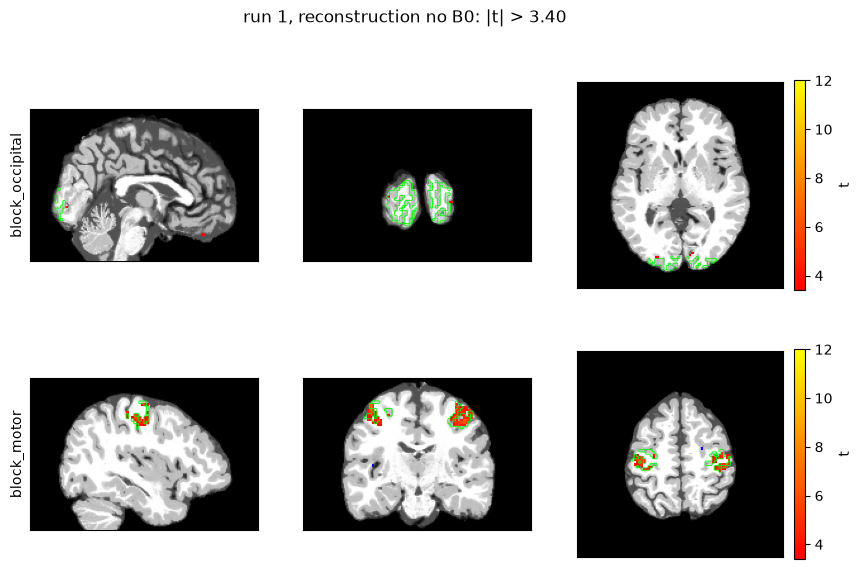

B0: 1031 of 1031 truly activated voxels above threshold; 2888 of 138926 others


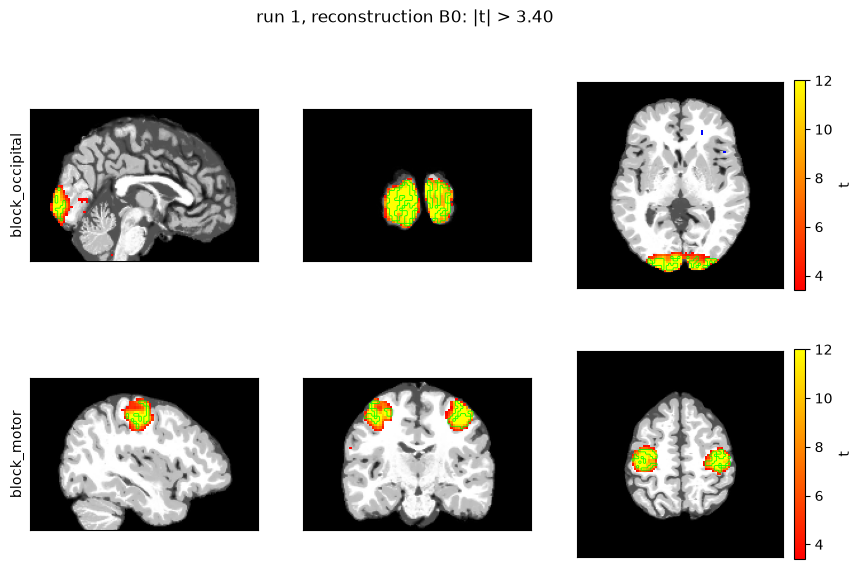

In [16]:
regressor = truth.canonical[0]  # one task: the same canonical regressor for both regions
T_THR = analysis.t_threshold(truth.n_frames, TR, p=0.001)
print(f"threshold: |t| > {T_THR:.2f} (nominal p < 0.001, "
      f"{len(analysis.low_band(truth.n_frames, TR)) - 3} degrees of freedom)")


# a shorter experiment for sections 7 and 8: the first 80 s (two cycles) of each run, which is
# also one separately reconstructed piece
N_SHORT = SEAMS[0] if SEAMS else truth.n_frames // 4
T_THR_SHORT = analysis.t_threshold(N_SHORT, TR, p=0.001)


def glm_of(fn_recon, tr_run, n=None):
    # (beta, t) over the brain voxels from the first n frames (None: all), cached next to the
    # reconstruction
    def cache(m):
        return fn_recon.replace("_recon.h5", f"_glm{m or ''}.npz")

    if not os.path.exists(cache(n)):
        x = analysis.load_series(fn_recon, brain)
        for m in (None, N_SHORT):
            beta, t = analysis.t_map(x[:, :m], tr_run.canonical[0][:m], TR)
            np.savez(cache(m), beta=beta.astype(np.float32), t=t.astype(np.float32))
    with np.load(cache(n)) as z:
        return z["beta"], z["t"]


glm, glm_short = ({label: [glm_of(run["recons"][label], tr_run, n)
                           for run, tr_run in zip(runs, truths)] for label in study.RECONS}
                  for n in (None, N_SHORT))
# the ceiling: the same GLM on the true, noise-free series (physiology included)
true_series = [analysis.true_signal(tr_run, brain, per_frame=True) for tr_run in truths]
glm["true signal"] = [analysis.t_map(x, tr_run.canonical[0], TR)
                      for x, tr_run in zip(true_series, truths)]
glm_short["true signal"] = [analysis.t_map(x[:, :N_SHORT], tr_run.canonical[0][:N_SHORT], TR)
                            for x, tr_run in zip(true_series, truths)]
del true_series
# the null: the true series with the activations switched off (physiology only)
physiology = [n for n in truth.mode_names if not n.startswith("block_")]
glm["true, task off"] = [
    analysis.t_map(analysis.true_signal(tr_run, brain, modes=physiology, per_frame=True),
                   tr_run.canonical[0], TR) for tr_run in truths]
outline = rois.any(axis=0)
for label in ("no B0", "B0"):
    t_vol = analysis.to_volume(glm[label][0][1], brain)
    n_in = int((t_vol[outline] > T_THR).sum())
    n_out = int(((np.abs(t_vol) > T_THR) & brain & ~outline).sum())
    print(f"{label}: {n_in} of {outline.sum()} truly activated voxels above threshold; "
          f"{n_out} of {(brain & ~outline).sum()} others")
    fig = analysis.overlay(truth, t_vol, T_THR, centers, vmax=12, outline=outline,
                           title=f"run 1, reconstruction {label}: |t| > {T_THR:.2f}")
    plt.show()

**What the threshold lets through.** The nominal rate is 0.1% of inactive
voxels. The table has the measured rate, over the four runs, by distance from
the nearest activated voxel (*inactive*: the true change is under 5% of the
activation's; section 7). Three things are in it.

*Next to the regions* the reconstruction puts activation in voxels that have
none: its resolution, not chance, and positive t.

*Far from them* the rate is the test's own calibration, and it is about right
on average but not run by run. The row "true, task off" is the same GLM on
the true series with the activations switched off: physiology only, nothing
to find. Its rate in each run is under the table: none in two runs, many times
the nominal rate in another. The BOLD-like fluctuations are four smooth
patterns shared by the whole brain, so when one of them happens to follow the
task in a run, a whole area passes together. The reconstructions' rates far
from the regions follow the same runs.

*The "true signal" row* (task on, no thermal noise) is above "task off"
everywhere. With nothing to hide it, the faint ringing that a band-limited
activation leaves across the image (real, well under 5% of the activation) is
itself significant where the physiological fluctuations are small.

In [17]:
active, inactive = analysis.truth_classes(truth, brain)
dist = ndimage.distance_transform_edt(~outline)[brain]  # voxels (2.4 mm) to the nearest activated
shells = ((0, 3), (3, 6), (6, 12), (12, np.inf))
print(f"inactive voxels above |t| > {T_THR:.2f} (%), by distance from an activated voxel\n")
print(f"{'':14s} {'all':>5s} " + " ".join(f"{f'{lo:g}-{hi:g} vox':>11s}" for lo, hi in shells)
      + f" {'positive t':>11s}")
print(f"{'voxels':12s} {inactive.sum():7d} "
      + " ".join(f"{int((inactive & (dist >= lo) & (dist < hi)).sum()):11d}" for lo, hi in shells))
far, per_run = inactive & (dist >= 6), {}
for label in ("true signal", "true, task off", "no B0", "B0"):
    above = np.stack([np.abs(t) > T_THR for _, t in glm[label]])  # (runs, voxels)
    sign = np.concatenate([t[inactive & (np.abs(t) > T_THR)] for _, t in glm[label]])
    cols = [100 * above[:, inactive & (dist >= lo) & (dist < hi)].mean() for lo, hi in shells]
    print(f"{label:14s} {100 * above[:, inactive].mean():5.3f} "
          + " ".join(f"{c:11.3f}" for c in cols) + f" {100 * (sign > 0).mean():10.0f}%")
    per_run[label] = 100 * above[:, far].mean(axis=1)
print("\n6 voxels or more from an activated voxel, run by run (%):")
for label, v in per_run.items():
    print(f"{label:14s} " + " ".join(f"{x:7.3f}" for x in v))

inactive voxels above |t| > 3.40 (%), by distance from an activated voxel

                 all     0-3 vox     3-6 vox    6-12 vox  12-inf vox  positive t
voxels        135994        2318        7915       26153       99608
true signal    1.729      17.494       6.068       1.740       1.014         46%
true, task off 0.417       1.111       0.824       0.409       0.371         47%
no B0          0.056       0.723       0.006       0.028       0.051         69%
B0             0.572      24.180       0.407       0.082       0.165         89%

6 voxels or more from an activated voxel, run by run (%):
true signal      0.473   0.548   2.541   1.097
true, task off   0.000   0.000   1.454   0.062
no B0            0.038   0.049   0.040   0.060
B0               0.085   0.033   0.318   0.155


**Do the seams matter?** Every seam is at the start of a task block, in every
run, so their effect on a task regression is not random. The control: replace
the three frames either side of each seam by a straight line between their
neighbours and fit again.

In [18]:
def mend(series, width=3):
    out = series.copy()
    for s in SEAMS:
        a, b = s - width - 1, s + width
        w = (np.arange(a + 1, b) - a) / (b - a)
        out[:, a + 1:b] = series[:, [a]] * (1 - w) + series[:, [b]] * w
    return out


for label, fn in run1["recons"].items():
    x = analysis.load_series(fn, brain)
    step = np.median(np.abs(np.diff(x, axis=1)), axis=0)  # per frame step, median over voxels
    usual = np.median(np.delete(step, [s - 1 for s in SEAMS]))
    t_as_is = glm[label][0][1]
    _, t_mended = analysis.t_map(mend(x), regressor, TR)
    auc = [analysis.roc(t, active, inactive)[3] for t in (t_as_is, t_mended)]
    print(f"{label:6s} step across a seam / usual frame step, median voxel: "
          + ", ".join(f"{step[s - 1] / usual:.1f}" for s in SEAMS)
          + ";  t map with the seams mended: correlation "
          f"{np.corrcoef(t_as_is, t_mended)[0, 1]:.4f},"
          f" rms difference {np.sqrt(np.mean((t_as_is - t_mended) ** 2)):.3f},"
          f" AUC {auc[0]:.4f} -> {auc[1]:.4f}")

no B0  step across a seam / usual frame step, median voxel: 3.9, 3.5, 4.2;  t map with the seams mended: correlation 0.9973, rms difference 0.073, AUC 0.8678 -> 0.8707


B0     step across a seam / usual frame step, median voxel: 4.7, 4.3, 5.4;  t map with the seams mended: correlation 0.9995, rms difference 0.063, AUC 0.9997 -> 0.9997


The recovered amplitude: the GLM's coefficient as a percentage of each voxel's
mean signal. The regressor is the canonical response, whose plateau-to-plateau
swing is about 2 (it runs from $-1$ at rest to about $+1$ on task), so a
coefficient of 1% means 2% between rest and task. The histograms show it
scaled to the regressor's peak, to compare with the 3%.

Inside the regions the reconstructions recover less than the truth. The table
under the figure asks whether that amplitude is lost or moved: it sums the
activation over each region together with the voxels within $r$ of it. A sum
that returns to 1 a few voxels out means the reconstruction spread the
activation over its surroundings (resolution); one that stays below 1 means it
attenuated it. With B0 the visual region's sum returns to 1 and the motor
region's to 0.9: mostly spread.

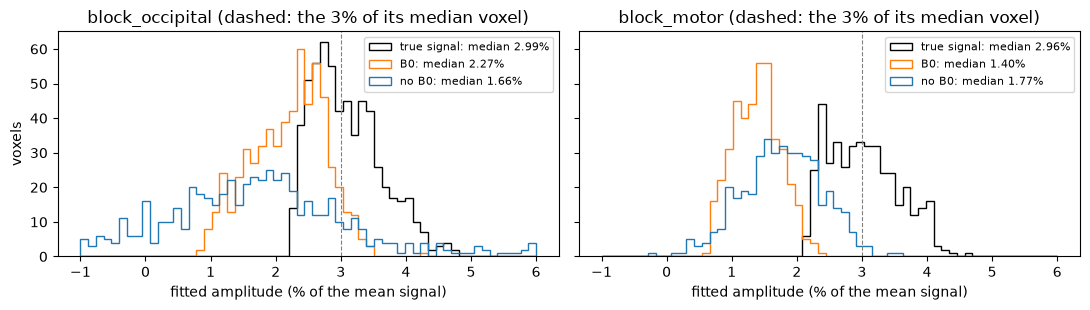

activation summed over a region and the voxels within r of it, relative to the truth

                           r = 0   r = 1   r = 2   r = 3   r = 5
no B0  block_occipital      0.49    0.80    0.98    1.13    1.29
no B0  block_motor          0.58    0.81    0.92    0.92    0.86


B0     block_occipital      0.71    0.96    1.06    1.10    1.13
B0     block_motor          0.46    0.70    0.87    0.91    0.83


In [19]:
fig, ax = plt.subplots(1, len(rois), figsize=(11, 3.2), sharey=True)
peak = np.abs(regressor - regressor.mean()).max()  # the regressor's own peak excursion
for k, (a_, name) in enumerate(zip(ax, names)):
    m = rois[k][brain]
    bins = np.linspace(-1, 6, 60)
    for label, color in (("true signal", "k"), ("B0", "C1"), ("no B0", "C0")):
        a_.hist(100 * peak * glm[label][0][0][m], bins=bins, histtype="step", color=color,
                label=f"{label}: median {100 * peak * np.median(glm[label][0][0][m]):.2f}%")
    a_.axvline(100 * truth.amps[k], color="0.5", lw=0.8, ls="--")
    a_.set_xlabel("fitted amplitude (% of the mean signal)")
    a_.set_title(f"{name} (dashed: the 3% of its median voxel)")
    a_.legend(fontsize=8)
ax[0].set_ylabel("voxels")
plt.tight_layout()
plt.show()

# where the missing amplitude went: the activation (coefficient x signal) summed over each region
# alone and over the region with the voxels around it, as a fraction of the true signal's
print("activation summed over a region and the voxels within r of it, relative to the truth\n")
print(f"{'':24s} " + " ".join(f"{f'r = {r}':>7s}" for r in (0, 1, 2, 3, 5)))
for label in ("no B0", "B0"):
    for k, name in enumerate(names):
        dist_k = ndimage.distance_transform_edt(~rois[k])
        act_vol = [analysis.to_volume(glm[which][0][0], brain) * truth.x0
                   for which in (label, "true signal")]
        total = [[v[(dist_k <= r) & brain].sum() for r in (0, 1, 2, 3, 5)] for v in act_vol]
        print(f"{label:6s} {name:17s} " + " ".join(f"{a / b:7.2f}" for a, b in zip(*total)))

## 7. ROC curves

A t-map becomes an activation map by thresholding, and every threshold trades
missed activations against false ones. The ROC curve shows the whole trade:
for each threshold, the **true positive rate** (the fraction of truly active
voxels above it, $p_A$) against the **false positive rate** (the fraction of
truly inactive voxels above it, $p_I$).

A simulation knows which voxels are which. *Active* are the truth's activated
voxels of both regions; *inactive* are brain voxels whose true change is under
5% of the activation's; voxels in between (partly activated, at a region's
edge) are left out. Each curve pools the four runs. "True signal" is the same
GLM on the noise-free true series: what a perfect acquisition and
reconstruction would give, limited only by the physiological fluctuations.

A 3% activation over 320 s is a strong signal, and a curve that hugs the
corner says little. So the dashed curves repeat the analysis on a shorter
experiment: the **first 80 s** (two cycles) of each run, which is also one
separately reconstructed piece. The area under the curve (AUC) is 1 for a
perfect map and 0.5 for a useless one; the left end of the curve, at false
positive rates of 0.1% to 1%, is where activation maps are thresholded.

1031 active voxels, 135994 inactive, 2932 in neither class

                           AUC  TPR at FPR 0.1%   at 1%   at 5%   AUC per run
true signal, 320 s      0.9999            1.000   1.000   1.000   1.0000 0.9999 0.9999 1.0000


B0, 320 s               0.9997            0.952   1.000   1.000   0.9997 0.9997 0.9997 0.9997
no B0, 320 s            0.8619            0.318   0.500   0.631   0.8678 0.8662 0.8542 0.8594


true signal, first 80 s  1.0000            1.000   1.000   1.000   1.0000 1.0000 1.0000 1.0000
B0, first 80 s          0.9986            0.854   0.980   0.996   0.9965 0.9992 0.9994 0.9993


no B0, first 80 s       0.6721            0.045   0.114   0.220   0.6629 0.6664 0.6795 0.6797


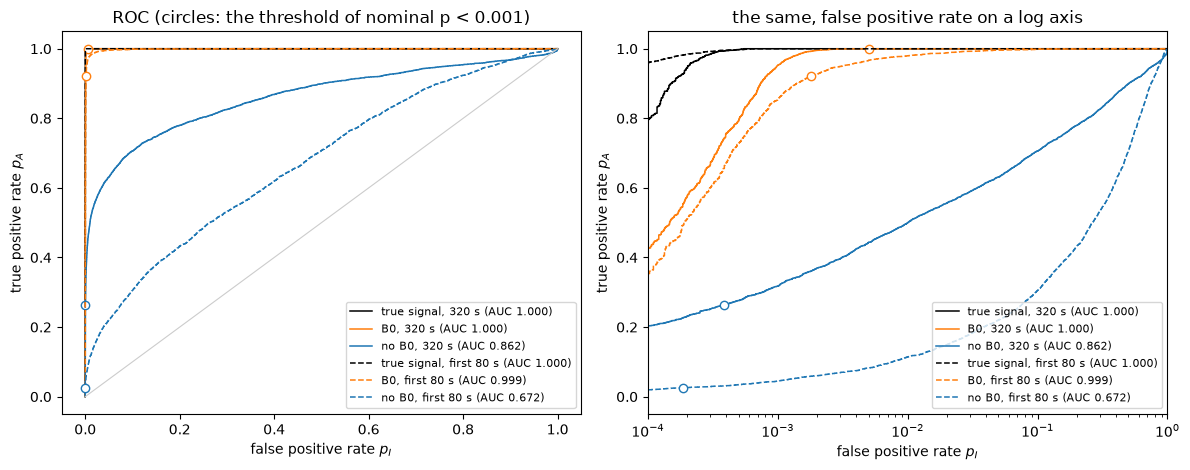

In [20]:
print(f"{active.sum()} active voxels, {inactive.sum()} inactive, "
      f"{brain.sum() - active.sum() - inactive.sum()} in neither class\n")
colors = {"true signal": "k", "B0": "C1", "no B0": "C0"}
act_all, inact_all = np.tile(active, N_RUNS), np.tile(inactive, N_RUNS)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
print(f"{'':22s} {'AUC':>7s} {'TPR at FPR 0.1%':>16s} {'at 1%':>7s} {'at 5%':>7s}   AUC per run")
for length, maps, thr_p, ls in (("320 s", glm, T_THR, "-"), ("first 80 s", glm_short, T_THR_SHORT,
                                                         "--")):
    for label, color in colors.items():
        pooled = np.concatenate([t for _, t in maps[label]])
        fpr, tpr, _, auc = analysis.roc(pooled, act_all, inact_all)
        per_run = [analysis.roc(t, active, inactive)[3] for _, t in maps[label]]
        at = [float(np.interp(x, fpr, tpr)) for x in (0.001, 0.01, 0.05)]
        print(f"{label + ', ' + length:22s} {auc:7.4f} {at[0]:16.3f} {at[1]:7.3f} {at[2]:7.3f}   "
              + " ".join(f"{v:.4f}" for v in per_run))
        f_thr, t_thr = analysis.rates(pooled, act_all, inact_all, [thr_p])
        for a_ in ax:
            a_.plot(fpr, tpr, color=color, ls=ls, lw=1.1,
                    label=f"{label}, {length} (AUC {auc:.3f})")
            if label != "true signal":
                a_.plot(f_thr, t_thr, "o", color=color, ms=6, mfc="w")
ax[0].plot([0, 1], [0, 1], "0.8", lw=0.8)
ax[0].set_title("ROC (circles: the threshold of nominal p < 0.001)")
ax[1].set_xscale("log")
ax[1].set_xlim(1e-4, 1)
ax[1].set_title("the same, false positive rate on a log axis")
for a_ in ax:
    a_.set_xlabel("false positive rate $p_I$")
    a_.set_ylabel("true positive rate $p_A$")
    a_.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

**Reading the curves** (numbers from the saved outputs). With the B0 model and
the whole run the map is close to perfect: at a false positive rate of 0.1%,
95% of the activated voxels are found, and 85% from the first 80 s alone.
Without it, 32% from the whole run and under 5% from 80 s: four times the scan
time does not make up for leaving the field out. The two reconstructions are
told apart at any length; what a 3% activation over 320 s cannot do is rank
reconstructions that both model the field, because they would all sit in the
corner. A shorter run or a weaker activation is the test for that.

## 8. Test-retest reliability, without the truth

A real study has no truth to draw an ROC curve from. Genovese, Noll and Eddy
(Magn Reson Med 1997;38:497) estimate one from repetition instead. Run the
same experiment $M$ times, threshold each run's map, and count for every voxel
in how many runs it was classified active: the **reliability map**
$R_v \in \{0, \dots, M\}$. If a proportion $\lambda$ of voxels is truly active,
and a truly active voxel is classified active with probability $p_A$ and an
inactive one with probability $p_I$, independently in each run, then

$$R_v \sim \lambda\,\mathrm{Binomial}(M, p_A) + (1 - \lambda)\,\mathrm{Binomial}(M, p_I),$$

and the three numbers follow by maximum likelihood from the histogram of
$R_v$ alone. Reliable voxels are the ones at 0 or at $M$.

With several thresholds on the same maps the fits share $\lambda$ (the
"dependent likelihood"): each voxel's result in a run is how many of the $K$
thresholds it reached, the model is a mixture of two multinomials, and the
tail sums of their probabilities are $p_A$ and $p_I$ at each threshold: an
ROC curve with no truth in it. `analysis.fit_mixed_binomial` fits both forms
by EM.

Here $M = 4$ (the least the model is used with; more are better), and the truth is there to check the answer against. The model is
fitted three times: to the 320 s runs reconstructed without and with B0, and
to the first 80 s of the runs with B0, where detection is not at its ceiling.
(The 80 s maps are thresholded at the same t values as the others; with their
21 degrees of freedom a nominal p < 0.001 would be t > 3.82 rather than 3.40.) Two things to
keep in mind when comparing. The model has two classes of voxel, while the
truth has a third: the partly activated voxels at the edge of each region,
which are neither fully active nor inactive and which the model must put in
one class or the other, so its $\lambda$ should fall between the proportion of
activated voxels and the proportion activated at all. And the model assumes
voxels are independent and alike, which neighbouring voxels sharing one
physiological fluctuation are not.

reliability map at t > 3.40: voxels classified active in k of 4 runs
   k:              0       1       2       3       4
   no B0            139176     188     104      97     392
     truly active      705      42      28      40     216
     truly inactive  135880      57      32      12      13
   B0               135210     826     287     303    3331
     truly active        0       0       0       0    1031
     truly inactive  134669     686     177     127     335
   B0, first 80 s   135855    1192     366     493    2051
     truly active        6      16      21      94     894
     truly inactive  134830     906      91      72      95


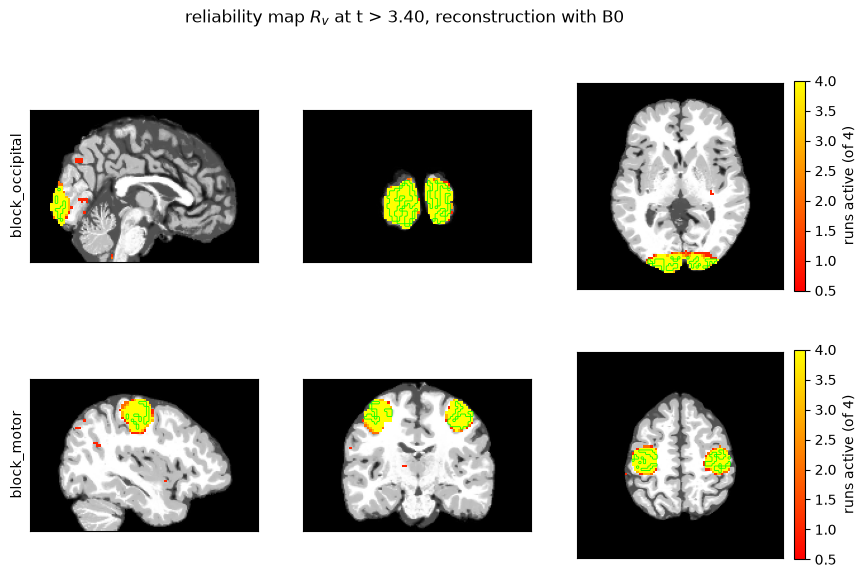

In [21]:
# (M, voxels) t maps of each case, and its color in the plots
t_runs = {"no B0": np.stack([t for _, t in glm["no B0"]]),
          "B0": np.stack([t for _, t in glm["B0"]]),
          "B0, first 80 s": np.stack([t for _, t in glm_short["B0"]])}
case_colors = {"no B0": "C0", "B0": "C1", "B0, first 80 s": "C2"}
rel = analysis.reliability_map(t_runs["B0"], T_THR)
print(f"reliability map at t > {T_THR:.2f}: voxels classified active in k of {N_RUNS} runs")
print("   k:        " + " ".join(f"{k:7d}" for k in range(N_RUNS + 1)))
for label in t_runs:
    r = analysis.reliability_map(t_runs[label], T_THR)
    print(f"   {label:15s} " + " ".join(f"{int((r == k).sum()):7d}" for k in range(N_RUNS + 1)))
    for cls, m in (("truly active", active), ("truly inactive", inactive)):
        print(f"     {cls:13s} " + " ".join(f"{int(((r == k) & m).sum()):7d}"
                                           for k in range(N_RUNS + 1)))
fig = analysis.overlay(truth, analysis.to_volume(rel, brain), 0.5, centers, vmax=N_RUNS,
                       outline=outline, two_sided=False, label=f"runs active (of {N_RUNS})",
                       title=f"reliability map $R_v$ at t > {T_THR:.2f}, reconstruction with B0")
plt.show()

In [22]:
thresholds = np.array([1.5, 2.0, 2.5, 3.0, T_THR, 4.0, 5.0, 6.0, 8.0])
# the model has two classes; the truth has a third, the partly activated voxels at each
# region's edge, which the model must put in one or the other
lam_strict, lam_any = active.mean(), (~inactive).mean()
fits = {}
print(f"true proportion of voxels: {lam_strict:.4f} activated, {lam_any:.4f} activated at all "
      "(the partly activated ones included)\n")
print(f"{'':15s} {'threshold':>9s} | {'lambda':>7s} {'p_A':>6s} {'p_I':>8s} |"
      f" {'true p_A':>8s} {'true p_I':>8s}    (one threshold at a time)")
for label in t_runs:
    pooled = t_runs[label].ravel()
    f_true, t_true = analysis.rates(pooled, act_all, inact_all, thresholds)
    for thr, ft, tt in zip(thresholds, f_true, t_true):
        fit1 = analysis.fit_mixed_binomial(analysis.levels(t_runs[label], [thr]), 1)
        print(f"{label:15s} {thr:9.2f} | {fit1.lam:7.4f} {fit1.p_active[0]:6.3f} "
              f"{fit1.p_inactive[0]:8.5f} | {tt:8.3f} {ft:8.5f}")
    fits[label] = (analysis.fit_mixed_binomial(analysis.levels(t_runs[label], thresholds),
                                               len(thresholds)), f_true, t_true)
    print()

true proportion of voxels: 0.0074 activated, 0.0283 activated at all (the partly activated ones included)

                threshold |  lambda    p_A      p_I | true p_A true p_I    (one threshold at a time)
no B0                1.50 |  0.0682  0.792  0.00876 |    0.631  0.04985
no B0                2.00 |  0.0273  0.808  0.00362 |    0.538  0.01573


no B0                2.50 |  0.0120  0.842  0.00135 |    0.432  0.00435
no B0                3.00 |  0.0065  0.854  0.00055 |    0.331  0.00114
no B0                3.40 |  0.0043  0.866  0.00033 |    0.262  0.00038


no B0                4.00 |  0.0024  0.868  0.00019 |    0.175  0.00007
no B0                5.00 |  0.0009  0.781  0.00008 |    0.068  0.00000


no B0                6.00 |  0.0002  0.663  0.00003 |    0.016  0.00000
no B0                8.00 |  0.1148  0.000  0.00000 |    0.000  0.00000



B0                   1.50 |  0.0768  0.760  0.04091 |    1.000  0.07265
B0                   2.00 |  0.0433  0.867  0.01988 |    1.000  0.03254


...

B0                   8.00 |  0.0162  0.925  0.00042 |    0.907  0.00076



B0, first 80 s       1.50 |  0.1044  0.661  0.04978 |    0.998  0.09225
B0, first 80 s       2.00 |  0.0481  0.765  0.02427 |    0.994  0.03847


B0, first 80 s       2.50 |  0.0297  0.859  0.01001 |    0.986  0.01467
B0, first 80 s       3.00 |  0.0234  0.892  0.00407 |    0.971  0.00584
B0, first 80 s       3.40 |  0.0208  0.893  0.00218 |    0.950  0.00310


B0, first 80 s       4.00 |  0.0179  0.876  0.00124 |    0.903  0.00147
B0, first 80 s       5.00 |  0.0135  0.822  0.00087 |    0.759  0.00058
B0, first 80 s       6.00 |  0.0098  0.730  0.00074 |    0.561  0.00025


B0, first 80 s       8.00 |  0.0043  0.484  0.00036 |    0.201  0.00003


All thresholds together (one shared $\lambda$), as an ROC curve: the points are
the model's estimates, from the four runs' classifications alone; the lines
are the true curves of section 7. The circled point maximizes the criterion
$c(\tau) = \lambda\,p_A(\tau) + (1 - \lambda)(1 - p_I(\tau))$, the estimated
fraction of voxels classified correctly.

no B0: lambda 0.0657 (truth: 0.0074 activated, 0.0283 at all); best threshold by the criterion: t > 1.50 (estimated p_A 0.806, p_I 0.00984; true 0.631, 0.04985)
B0: lambda 0.0334 (truth: 0.0074 activated, 0.0283 at all); best threshold by the criterion: t > 3.40 (estimated p_A 0.810, p_I 0.00093; true 1.000, 0.00508)


B0, first 80 s: lambda 0.0367 (truth: 0.0074 activated, 0.0283 at all); best threshold by the criterion: t > 3.00 (estimated p_A 0.608, p_I 0.00261; true 0.971, 0.00584)


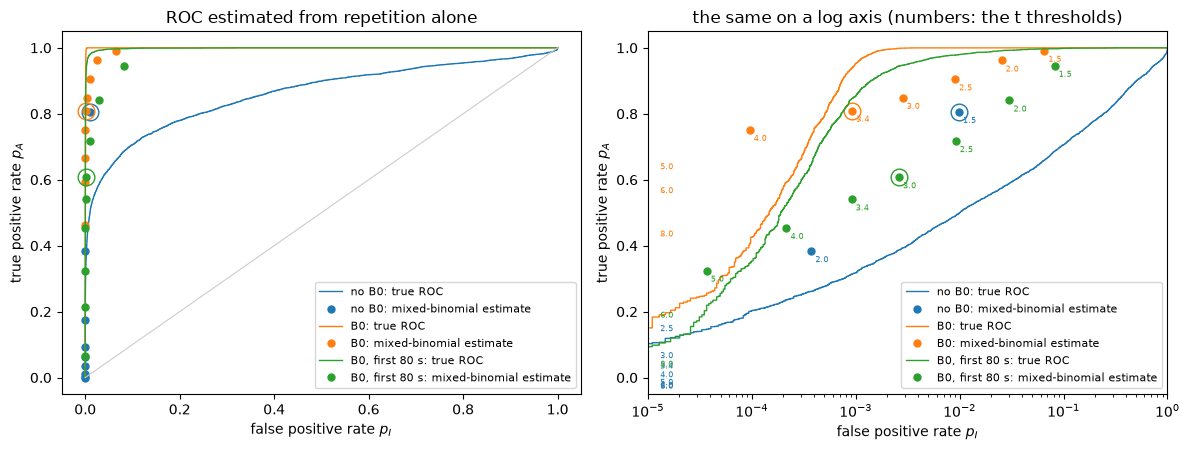

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
for label, color in case_colors.items():
    fit, f_true, t_true = fits[label]
    fpr, tpr, _, _ = analysis.roc(t_runs[label].ravel(), act_all, inact_all)
    crit = fit.lam * fit.p_active + (1 - fit.lam) * (1 - fit.p_inactive)
    best = int(np.argmax(crit))
    print(f"{label}: lambda {fit.lam:.4f} (truth: {lam_strict:.4f} activated, {lam_any:.4f} at "
          "all); best threshold by the criterion: "
          f"t > {thresholds[best]:.2f} (estimated p_A {fit.p_active[best]:.3f}, "
          f"p_I {fit.p_inactive[best]:.5f}; true {t_true[best]:.3f}, {f_true[best]:.5f})")
    for a_ in ax:
        a_.plot(fpr, tpr, color=color, lw=1, label=f"{label}: true ROC")
        a_.plot(fit.p_inactive, fit.p_active, "o", color=color, ms=5,
                label=f"{label}: mixed-binomial estimate")
        a_.plot(fit.p_inactive[best], fit.p_active[best], "o", color=color, ms=12, mfc="none")
    for thr, x, y in zip(thresholds, fit.p_inactive, fit.p_active):
        ax[1].annotate(f"{thr:.1f}", (max(x, 1.2e-5), y), fontsize=6, color=color,
                       xytext=(3, -8), textcoords="offset points")
ax[0].plot([0, 1], [0, 1], "0.8", lw=0.8)
ax[1].set_xscale("log")
ax[1].set_xlim(1e-5, 1)
ax[0].set_title("ROC estimated from repetition alone")
ax[1].set_title("the same on a log axis (numbers: the t thresholds)")
for a_ in ax:
    a_.set_xlabel("false positive rate $p_I$")
    a_.set_ylabel("true positive rate $p_A$")
    a_.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

**What the model sees, and what it cannot** (numbers from the saved outputs,
at t > 3.40).

*With B0* the model's proportion of active voxels is 2.8%: the proportion
activated **at all** (2.83%), not the fully activated ones (0.74%). Its active
class is whatever lights up reproducibly, and the partly activated edges do.
That is why its $p_A$ (0.95) is below the true 1.00, which counts only the
fully activated voxels. Its $p_I$ (0.0015) is below the true 0.0051 for a
different reason: most false positives are next to the regions, where the
reconstruction spreads the activation, and they recur. 335 truly inactive
voxels are above threshold in all four runs. To the model a voxel that is
active every time is active; it measures reproducibility, and a reproducible
error counts in favour.

*Without B0* this goes badly wrong. The model reports $p_A = 0.87$ where the
truth is 0.26. Of the 1031 activated voxels, 705 are above threshold in no run
at all (most of the visual cortex) and sit in the histogram with the inactive
ones; the model's active class is the 0.4% of voxels this reconstruction finds
every time, and those it does find reliably. A reconstruction that misses the
same activation in every run looks reliable. Test-retest cannot tell that from
a brain with a smaller activation; the truth can.

*All thresholds together* the estimated points lie below the true curves: at
the false positive rate the model assigns to t > 3.40 with B0 (0.0009) the true
curve is already at 0.95, and the model says 0.81. The model allows two kinds
of voxel, each with one set of rates, independent between runs. Here the
active voxels differ in amplitude, the inactive ones in noise level (tissue,
distance from the regions), and errors repeat across runs, so the fit is a
summary of reproducibility, not an estimate of the true ROC. The tutorial this
section follows lists these assumptions and expects their misfit to be
negligible in most applications; a reconstruction with a systematic error is a
case where it is not.

So for comparing reconstructions: the reliability model also favours the one
with B0 (eight times as many voxels above threshold in all four runs, and a
higher $p_A$), but only the ROC against the truth shows how large the gap is.

The model also gives every voxel a probability of being truly active, given how
it was classified in the four runs at all the thresholds. Thresholded at one
half, that is an activation map from the whole study.

posterior > 0.5: 4664 voxels; 1031 of 1031 truly active, 1228 of 135994 truly inactive, 2405 partly activated


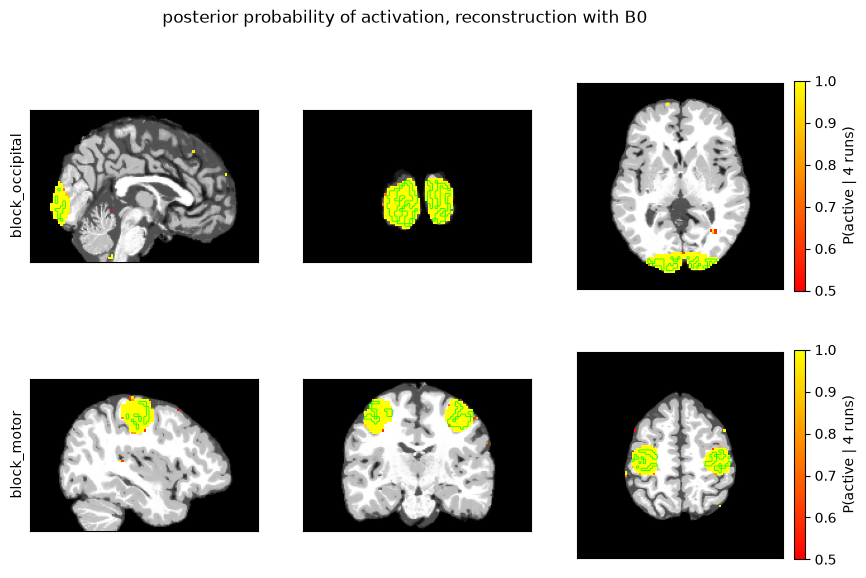

In [24]:
fit = fits["B0"][0]
post = analysis.to_volume(fit.posterior, brain)
called = fit.posterior > 0.5
print(f"posterior > 0.5: {called.sum()} voxels; {int((called & active).sum())} of {active.sum()} "
      f"truly active, {int((called & inactive).sum())} of {inactive.sum()} truly inactive, "
      f"{int((called & ~active & ~inactive).sum())} partly activated")
fig = analysis.overlay(truth, post, 0.5, centers, vmax=1.0, outline=outline, two_sided=False,
                       label="P(active | 4 runs)",
                       title="posterior probability of activation, reconstruction with B0")
plt.show()

## Where to go from here

- **Another task**: `SessionConfig(activations=(...))`, one
  `simulate_fmri.session.Activation(region, task_s, rest_s, onset, delay,
  amplitude)` per region; `'occipital'` and `'motor'` exist on both phantoms.
- **A weaker activation**: `amplitude=0.015` is 3% between task and rest. The
  3% peak used here is strong enough that the 320 s maps with B0 are close to
  perfect, which is why section 7 also looks at 80 s.
- **Switch effects off** to see what each costs: `SessionConfig(b0_scale=0)`,
  `noise=0`, `physio=None`, `activation=False`, `delay=0, oe_phase=(0, 0)`,
  `grid_factor=1`.
- **Another protocol**: change `params.py` (`R`, `ETL`, `sampling_method`,
  `epi_trajectory`, resolution) and `DURATION`, and rerun from the top into
  another `OUT`.
- **Other reconstructions**: add entries to `study.RECONS` (any `recon.sense`
  setting); sections 6 to 8 compare whatever is there.
- **More repetitions**: raise `N_RUNS`; the reliability model's estimates
  tighten with $M$.
- **From the command line**: `python -m simulate_fmri.study OUT --duration 320
  --runs 4` runs the whole study; `python -m simulate_fmri.session` one
  session; `python -m recon.testbed score` scores a reconstruction (see
  `README.md`).